In [2]:
import numpy as np # linear algebra
import pandas as pd 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, chi2_contingency

In [4]:
df = pd.read_csv("Sales_with_NaNs_v1.3.csv")


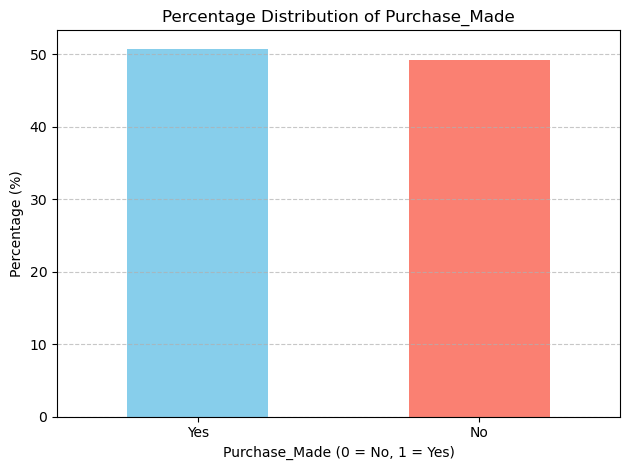

In [5]:

# Calculate percentage of each class in the target column
target_counts = df['Purchase_Made'].value_counts(normalize=True) * 100

# Plot bar chart
target_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Percentage Distribution of Purchase_Made')
plt.ylabel('Percentage (%)')
plt.xlabel('Purchase_Made (0 = No, 1 = Yes)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



Distribution of 'Group':
Group
Control      4300
Treatment    4299
Name: count, dtype: int64

Proportions:
Group
Control      0.500058
Treatment    0.499942
Name: count, dtype: float64


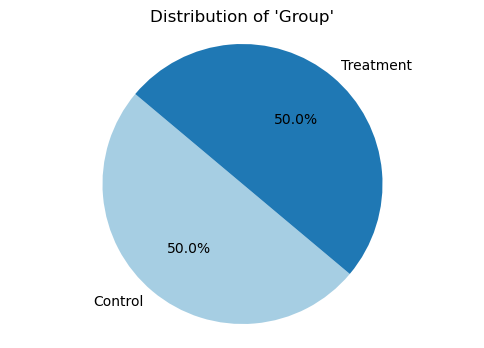

Distribution of 'Customer_Segment':
Customer_Segment
Low Value       2699
Medium Value    2697
High Value      2638
Name: count, dtype: int64

Proportions:
Customer_Segment
Low Value       0.335947
Medium Value    0.335698
High Value      0.328354
Name: count, dtype: float64


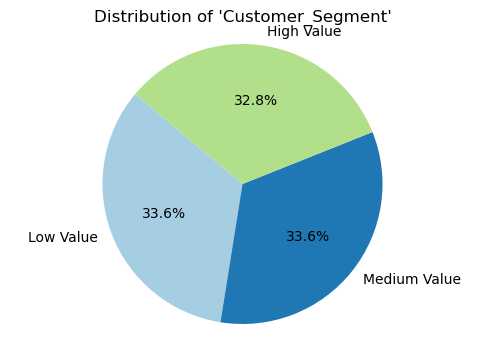

Distribution of 'Purchase_Made':
Purchase_Made
Yes    4667
No     4528
Name: count, dtype: int64

Proportions:
Purchase_Made
Yes    0.507558
No     0.492442
Name: count, dtype: float64


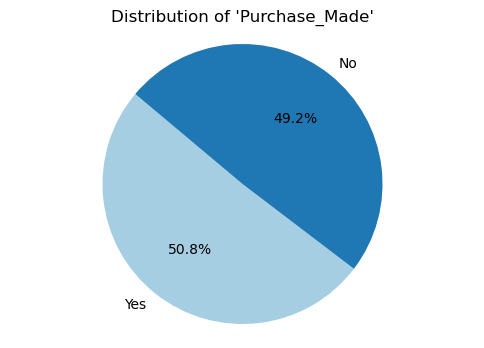

In [20]:
def check_balance_pie(column_name):
    print(f"Distribution of '{column_name}':")
    counts = df[column_name].value_counts()
    print(counts)
    print("\nProportions:")
    proportions = counts / counts.sum()
    print(proportions)
    # pie chart
    plt.figure(figsize=(6, 4))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
    plt.title(f"Distribution of '{column_name}'")
    plt.axis('equal')  # Equal aspect ratio ensures the pie chart is a circle.
    plt.show()

check_balance_pie('Group')
check_balance_pie('Customer_Segment')
check_balance_pie('Purchase_Made')

Analysis of Numerical Columns:

Statistics for Column: Sales_Before
Mean: 203.72
Median: 203.32
Variance: 3055.11
Standard Deviation: 55.27
----------------------------------------

Statistics for Column: Sales_After
Mean: 280.46
Median: 273.13
Variance: 7337.56
Standard Deviation: 85.66
----------------------------------------

Statistics for Column: Customer_Satisfaction_Before
Mean: 70.25
Median: 69.49
Variance: 287.54
Standard Deviation: 16.96
----------------------------------------

Statistics for Column: Customer_Satisfaction_After
Mean: 73.87
Median: 73.84
Variance: 328.64
Standard Deviation: 18.13
----------------------------------------


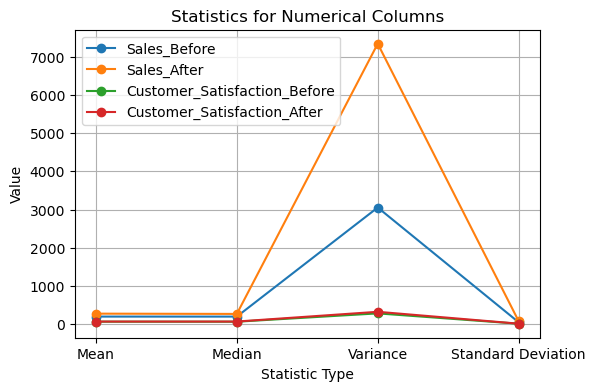

In [22]:
# Function to calculate and plot statistics for numerical columns
def analyze_and_plot_numerical_columns(dataframe):
    print("Analysis of Numerical Columns:")
    
    # Create a figure for the plots
    plt.figure(figsize=(6, 4))

    for column in dataframe.columns:
        # Check if the column is numerical
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            # Calculate statistics
            mean_val = dataframe[column].mean()
            median_val = dataframe[column].median()
            variance_val = dataframe[column].var()
            std_dev_val = dataframe[column].std()
            # Print statistics
            print(f"\nStatistics for Column: {column}")
            print(f"Mean: {mean_val:.2f}")
            print(f"Median: {median_val:.2f}")
            print(f"Variance: {variance_val:.2f}")
            print(f"Standard Deviation: {std_dev_val:.2f}")
            print("-" * 40)
            
            # Plot the statistics for the column
            plt.plot([1, 2, 3, 4], [mean_val, median_val, variance_val, std_dev_val], marker='o', label=column)
    
    # Set up plot
    plt.title("Statistics for Numerical Columns")
    plt.xlabel("Statistic Type")
    plt.ylabel("Value")
    plt.xticks([1, 2, 3, 4], ['Mean', 'Median', 'Variance', 'Standard Deviation'])
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

# Call the function
analyze_and_plot_numerical_columns(df)

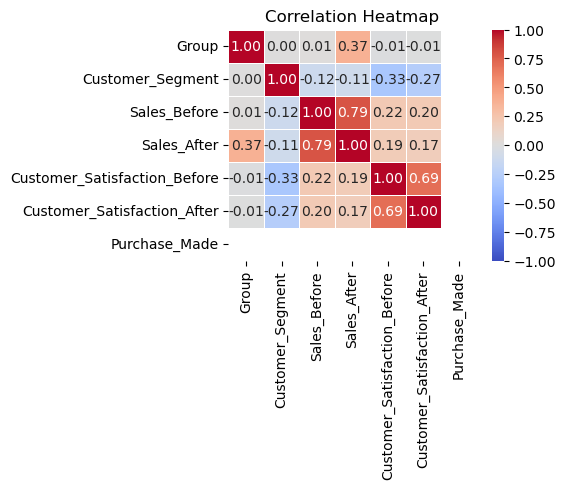

In [12]:
def plot_correlation_heatmap(dataframe):
    # Select only numerical columns
    numerical_columns = dataframe.select_dtypes(include=['number']).columns

    # Calculate the correlation matrix for numerical columns
    corr_matrix = dataframe[numerical_columns].corr()

    # Plot the heatmap using seaborn
    plt.figure(figsize=(4, 3))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
    
    # Set the title of the plot
    plt.title("Correlation Heatmap")
    plt.show()

plot_correlation_heatmap(df)

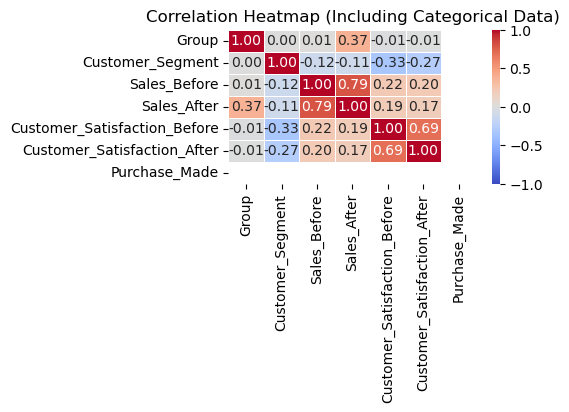

In [9]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

def encode_categorical_columns(dataframe):
    le = LabelEncoder()  # Initialize the label encoder
    categorical_columns = dataframe.select_dtypes(include=['object']).columns  # Identify categorical columns
    
    for column in categorical_columns:
        dataframe[column] = le.fit_transform(dataframe[column])  # Apply label encoding
    
    return dataframe
df_encoded = encode_categorical_columns(df)


def plot_correlation_heatmap(dataframe):
    corr_matrix = dataframe.corr()
    
    plt.figure(figsize=(4, 2))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

    plt.title("Correlation Heatmap (Including Categorical Data)")
    plt.show()


plot_correlation_heatmap(df_encoded)


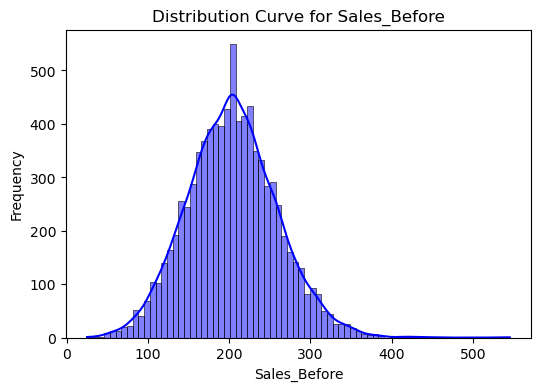

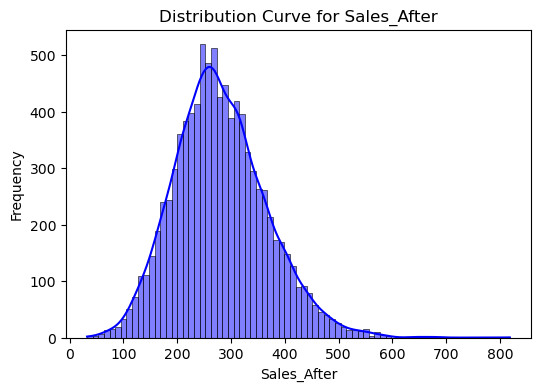

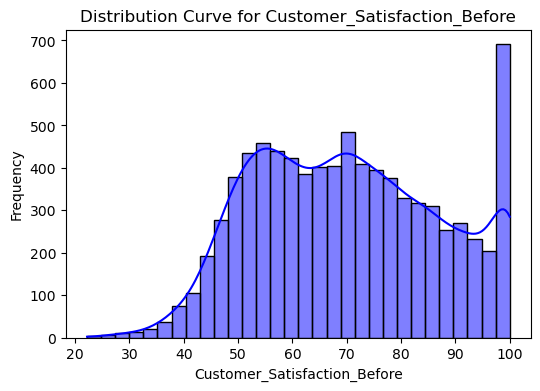

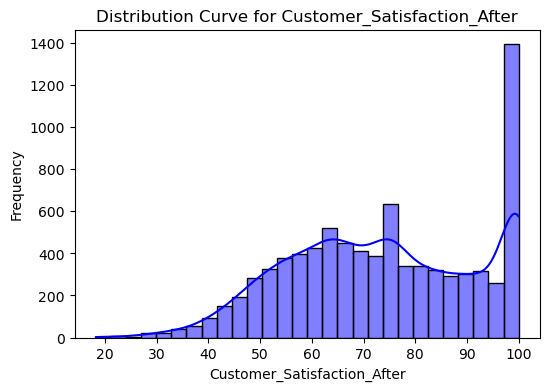


Range (Min and Max) for Each Numeric Column:

     Sales_Before  Sales_After  Customer_Satisfaction_Before  \
min     24.852966    32.414352                     22.202441   
max    545.422547   818.219997                    100.000000   

     Customer_Satisfaction_After  
min                    18.224938  
max                   100.000000  


In [28]:

# Select only numeric columns
numeric_cols = [
    "Sales_Before",
    "Sales_After",
    "Customer_Satisfaction_Before",
    "Customer_Satisfaction_After"
]

# Plot distribution (curve) for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, color='blue')  # kde=True draws the curve
    plt.title(f"Distribution Curve for {col}")
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Find the range (min and max) for each numeric column
ranges = df[numeric_cols].agg(['min', 'max'])
print("\nRange (Min and Max) for Each Numeric Column:\n")
print(ranges)


In [29]:

# Find number of missing values in each column
missing_values = df.isnull().sum()

# Find percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

# Combine and display nicely
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage
})

print(missing_summary)


                              Missing Values  Missing Percentage (%)
Group                                      0                    0.00
Customer_Segment                           0                    0.00
Sales_Before                            1522                   15.22
Sales_After                              767                    7.67
Customer_Satisfaction_Before            1670                   16.70
Customer_Satisfaction_After             1640                   16.40
Purchase_Made                              0                    0.00


In [33]:

# Returns the index positions where NaNs exist
nan_positions = np.argwhere(pd.isnull(df).values)

for pos in nan_positions:
    row_idx, col_idx = pos
    print(f"Missing value at Row {row_idx}, Column '{df.columns[col_idx]}'")


Missing value at Row 0, Column 'Customer_Satisfaction_After'
Missing value at Row 4, Column 'Sales_After'
Missing value at Row 10, Column 'Customer_Satisfaction_After'
Missing value at Row 11, Column 'Sales_Before'
Missing value at Row 12, Column 'Customer_Satisfaction_Before'
Missing value at Row 14, Column 'Customer_Satisfaction_After'
Missing value at Row 18, Column 'Customer_Satisfaction_After'
Missing value at Row 20, Column 'Customer_Satisfaction_Before'
Missing value at Row 23, Column 'Customer_Satisfaction_Before'
Missing value at Row 26, Column 'Sales_After'
Missing value at Row 29, Column 'Customer_Satisfaction_Before'
Missing value at Row 31, Column 'Sales_Before'
Missing value at Row 31, Column 'Customer_Satisfaction_After'
Missing value at Row 33, Column 'Sales_Before'
Missing value at Row 34, Column 'Customer_Satisfaction_After'
Missing value at Row 36, Column 'Sales_After'
Missing value at Row 37, Column 'Customer_Satisfaction_After'
Missing value at Row 39, Column 'Sale

In [5]:

# Loop through each column
for col in df.columns:
    if df[col].dtype == 'object':  # Categorical columns
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
    else:  # Numerical columns
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)

# (Optional) Check if any missing values are left
print(df.isnull().sum())


Group                           0
Customer_Segment                0
Sales_Before                    0
Sales_After                     0
Customer_Satisfaction_Before    0
Customer_Satisfaction_After     0
Purchase_Made                   0
dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16388\752313618.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16388\752313618.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [ ]:
from sklearn.preprocessing import LabelEncoder

categories = ['Low', 'Medium', 'High']
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(categories)
print(encoded_labels)

[1 2 0]


In [6]:

# Convert 'Purchase_Made' column from Yes/No to 1/0
df['Purchase_Made'] = df['Purchase_Made'].map({'Yes': 1, 'No': 0})

# (Optional) Check the result
print(df['Purchase_Made'].head())


0    0
1    1
2    0
3    1
4    1
Name: Purchase_Made, dtype: int64


In [8]:

# Convert 'Group' column to numerical values
df['Group'] = df['Group'].map({'Control': 0, 'Treatment': 1})

# Optional: Preview the changes
print(df['Group'].head())


0    0
1    1
2    0
3    0
4    0
Name: Group, dtype: int64


In [6]:

# Convert categorical columns to numerical format
df['Group'] = df['Group'].map({'Control': 0, 'Treatment': 1})
df['Purchase_Made'] = df['Purchase_Made'].map({'No': 0, 'Yes': 1})

# Optional: Convert any other categorical column (e.g., Customer_Segment)
# df['Customer_Segment'] = df['Customer_Segment'].astype('category').cat.codes

# Show a fraction (first 10 rows) of the updated DataFrame
print(df.head(10))


   Group Customer_Segment  Sales_Before  Sales_After  \
0    0.0       High Value    240.548359   300.007568   
1    1.0       High Value    246.862114   381.337555   
2    0.0       High Value    156.978084   179.330464   
3    0.0     Medium Value    192.126708   229.278031   
4    NaN       High Value    229.685623          NaN   
5    1.0              NaN    135.573003   218.559988   
6    0.0       High Value    191.713918   222.409356   
7    0.0        Low Value    173.752555   213.168232   
8    NaN       High Value    208.308577   248.178830   
9    1.0       High Value    235.071493   352.756872   

   Customer_Satisfaction_Before  Customer_Satisfaction_After  Purchase_Made  
0                     74.684767                          NaN            0.0  
1                    100.000000                   100.000000            1.0  
2                     98.780735                   100.000000            0.0  
3                     49.333766                    39.811841           